# Noise Hand Calculations Using the Level 1 Model

Este notebook calcula a mano el ruido de un NMOS con el modelo de primer orden (Level 1) de `razavi_cmos_noise.lib` y lo compara contra una simulación `.noise` de ngspice (`Noise_Razavi.cir`). Las unidades son SI: metros, volts, amperes, hertz; las densidades espectrales están en V$^2$/Hz o A$^2$/Hz.

Se estudian tres circuitos de fuente común, todos con $V_{GS}=0.9$ V, $W=1\,\mu$m y $L=0.18\,\mu$m, que comparten el mismo transistor:

| Circuito | Carga | Qué aísla |
|---|---|---|
| **A** | Inductor ideal (corto en DC, abierto en AC) desde 0.9 V | El ruido del transistor solo ($V_{DS}=0.9$ V) |
| **B** | $R_D=10\,\text{k}\Omega$ desde $V_{DD}=1.8$ V | El ruido del transistor más el de la resistencia de carga |
| **C** | Igual que A, con $r_d=r_s=200\,\Omega$ en serie con drenador y fuente | El ruido de las resistencias parásitas |

El Level 1 de SPICE genera tres fuentes de ruido: térmico del canal, flicker (1/f) y térmico de $r_d$ y $r_s$. Este notebook parte de sus expresiones y de las ecuaciones de pequeña señal ya corregidas en `Hand_Calculations.ipynb`.

## Imports

Se cargan NumPy y Matplotlib para los cálculos y las gráficas, `spicelib` para leer los archivos `.raw` de ngspice, y `prettytable` y `si_prefix` para mostrar los resultados en notación de ingeniería. Si la fuente Arial no está instalada, Matplotlib usa otra de la lista sin mostrar advertencias.

In [1]:
import logging
import os
import re

import numpy as np
import matplotlib.pyplot as plt

from spicelib import RawRead

from si_prefix import si_format as num2eng
from prettytable import PrettyTable

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

C_HAND = "#2a78d6"     # calculo a mano
C_SIM = "#eb6834"      # ngspice
C_AUX = "#52514e"      # lineas auxiliares

## Constantes y parámetros del modelo

La densidad espectral del ruido térmico depende de la temperatura de la simulación. ngspice usa `temp=27` °C, es decir $T=300.15$ K. La capacitancia de óxido por unidad de área es

$$C_{ox}=\frac{\epsilon_{ox}}{t_{ox}}, \qquad \epsilon_{ox}=3.9\,\epsilon_0,$$

con $\epsilon_0=8.854214871\times10^{-12}$ F/m, el valor que usa ngspice.

Además de los parámetros de `Hand_Calculations.ipynb`, el ruido necesita:

- $K_F$ y $A_F$: coeficiente y exponente del ruido flicker.
- $r_d$ y $r_s$: resistencias serie de drenador y fuente, que aportan su propio ruido térmico $4kT/R$.

Los valores de $K_F$ y $A_F$ son didácticos, elegidos para que la esquina del ruido 1/f quede cerca de 84 kHz con esta geometría. Para un caso real, $K_F$ debe calibrarse con datos del PDK o medidos.

In [2]:
# Constantes fisicas y temperatura (ngspice: temp = 27 C)
k = 1.380649e-23        # Constante de Boltzmann (J/K)
TEMP = 27.0             # Temperatura (C)
T = TEMP + 273.15       # Temperatura (K)
eps0 = 8.854214871e-12  # Permitividad del vacio (F/m)

# Geometria (m) y polarizacion (V)
W = 1e-6
L = 0.18e-6
VGS = 0.9
VDD = 1.8
VDS_A = 0.9             # Circuitos A y C: drenador fijado a 0.9 V
RD = 10e3               # Circuito B: resistencia de carga (ohm)

# Parametros Level 1 (mismos que Hand_Calculations.ipynb)
kp = 100e-6             # Parametro de transconductancia de proceso (A/V**2)
VTH0 = 0.4              # Voltaje de umbral con VSB = 0 (V)
gamma = 0.4             # Coeficiente de efecto de cuerpo (V**0.5)
phi = 0.3               # Potencial de superficie (V)
lmbda = 0.1             # Modulacion de longitud de canal (1/V)
tox = 40e-10            # Espesor de oxido (m)

# Parametros de ruido (razavi_cmos_noise.lib)
kf = 5e-32              # Coeficiente flicker
af = 1.0                # Exponente flicker
rd = 200.0              # Resistencia serie de drenador, circuito C (ohm)
rs = 200.0              # Resistencia serie de fuente, circuito C (ohm)

# Capacitancias que cargan el nodo de salida (para el ruido de salida a alta frecuencia)
CGDO = 9.548e-10        # Traslape compuerta-drenador (F/m)
Cj, Cjsw, LD = 9.81e-4, 1.19e-10, 0.48e-6
AS = W * LD
PS = 2 * W + 2 * LD

Cox = 3.9 * eps0 / tox
beta = kp * W / L
Cdb = Cj * AS + Cjsw * PS         # Capacitancia de union drenador-cuerpo
Cgd = CGDO * W                    # En saturacion solo queda el traslape
Cout = Cdb + Cgd                  # La compuerta esta a tierra en AC: ambas ven el nodo de salida

print(f"T = {T:.2f} K, 4kT = {4*k*T:.4e} J, Cox = {num2eng(Cox)}F/m^2, beta = {num2eng(beta)}A/V^2, Cout = {num2eng(Cout)}F")

T = 300.15 K, 4kT = 1.6576e-20 J, Cox = 8.6 mF/m^2, beta = 555.6 µA/V^2, Cout = 1.8 fF


## Punto de operación

El ruido del canal depende de $g_m$ y de $I_D$, así que primero se calcula el punto de operación con las mismas ecuaciones de `Hand_Calculations.ipynb`:

$$V_{TH}=V_{TH0}+\gamma\left(\sqrt{\phi+V_{SB}}-\sqrt{\phi}\right), \qquad V_{ov}=V_{GS}-V_{TH},$$
$$I_D=\frac{1}{2}k_p\frac{W}{L}V_{ov}^2(1+\lambda V_{DS}), \qquad g_m=k_p\frac{W}{L}V_{ov}(1+\lambda V_{DS}),$$
$$g_{mb}=g_m\frac{\gamma}{2\sqrt{\phi+V_{SB}}}, \qquad g_{ds}=\frac{\lambda I_D}{1+\lambda V_{DS}}.$$

### Circuito A

Con la carga ideal, $V_{DS}=0.9$ V y $V_{SB}=0$.

### Circuito B

El drenador está conectado a $V_{DD}$ por $R_D$, así que $V_{DS}=V_{DD}-R_DI_D$ y $I_D$ depende de $V_{DS}$ por la modulación de canal. Con $I_0=\frac{1}{2}k_p\frac{W}{L}V_{ov}^2$ y $I_D=I_0(1+\lambda V_{DS})$ se despeja

$$V_{DS}=\frac{V_{DD}-R_DI_0}{1+\lambda R_DI_0}.$$

### Circuito C

Con $r_s$ y $r_d$ en serie, el transistor intrínseco ve voltajes distintos a los externos:

$$V_{GS}'=V_{G}-I_Dr_s, \qquad V_{SB}'=I_Dr_s, \qquad V_{DS}'=V_{D}-I_D(r_d+r_s).$$

Como $V_{GS}'$, $V_{SB}'$ y $V_{DS}'$ dependen de $I_D$, y $I_D$ depende de ellos, el punto de operación se resuelve numéricamente con bisección sobre $I_D$.

In [3]:
def vth(VSB):
    return VTH0 + gamma * (np.sqrt(phi + VSB) - np.sqrt(phi))


def op_nmos(VGS_, VDS_, VSB_=0.0):
    """Punto de operacion y parametros de pequena senal en saturacion (Level 1)."""
    vov = VGS_ - vth(VSB_)
    ID = 0.5 * beta * vov**2 * (1 + lmbda * VDS_)
    gm = beta * vov * (1 + lmbda * VDS_)
    gmb = gm * gamma / (2 * np.sqrt(phi + VSB_))
    gds = lmbda * ID / (1 + lmbda * VDS_)
    return dict(VGS=VGS_, VDS=VDS_, VSB=VSB_, VTH=vth(VSB_), Vov=vov, VDSat=vov,
                ID=ID, gm=gm, gmb=gmb, gds=gds)


# --- Circuito A: carga ideal
opA = op_nmos(VGS, VDS_A)

# --- Circuito B: carga resistiva RD
I0 = 0.5 * beta * (VGS - vth(0))**2
VDS_B = (VDD - RD * I0) / (1 + lmbda * RD * I0)
opB = op_nmos(VGS, VDS_B)


# --- Circuito C: rd y rs en serie (bisecccion sobre ID)
def op_with_rs(VG, VD, rd_, rs_):
    def id_model(I):
        VSBi = I * rs_
        vov = VG - I * rs_ - vth(VSBi)
        vdsi = VD - I * (rd_ + rs_)
        return 0.5 * beta * max(vov, 0.0)**2 * (1 + lmbda * vdsi)

    lo, hi = 0.0, 1e-3
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if id_model(mid) - mid > 0:
            lo = mid
        else:
            hi = mid
    I = 0.5 * (lo + hi)
    return op_nmos(VG - I * rs_, VD - I * (rd_ + rs_), I * rs_)


opC = op_with_rs(VGS, VDS_A, rd, rs)

myTable = PrettyTable(["Parametro", "A (carga ideal)", "B (RD = 10k)", "C (rd, rs)"])
for name, key, unit in [("VDS (interno)", "VDS", "V"), ("VTH", "VTH", "V"), ("VDSat", "VDSat", "V"),
                        ("ID", "ID", "A"), ("gm", "gm", "S"), ("gds", "gds", "S"), ("gmb", "gmb", "S")]:
    myTable.add_row([name] + [num2eng(float(o[key])) + unit for o in (opA, opB, opC)])
print(myTable)
for lab, o in (("A", opA), ("B", opB), ("C", opC)):
    assert o["VDS"] >= o["VDSat"], f"Circuito {lab} fuera de saturacion"
print("Los tres circuitos estan en saturacion.")

+---------------+-----------------+--------------+------------+
|   Parametro   | A (carga ideal) | B (RD = 10k) | C (rd, rs) |
+---------------+-----------------+--------------+------------+
| VDS (interno) |     900.0 mV    |    1.0 V     |  872.1 mV  |
|      VTH      |     400.0 mV    |   400.0 mV   |  405.0 mV  |
|     VDSat     |     500.0 mV    |   500.0 mV   |  481.0 mV  |
|       ID      |     75.7 µA     |   76.6 µA    |  69.9 µA   |
|       gm      |     302.8 µS    |   306.5 µS   |  290.5 µS  |
|      gds      |      6.9 µS     |    6.9 µS    |   6.4 µS   |
|      gmb      |     110.6 µS    |   111.9 µS   |  103.7 µS  |
+---------------+-----------------+--------------+------------+
Los tres circuitos estan en saturacion.


## Ruido térmico del canal

En el Level 1 el ruido térmico del canal es una fuente de corriente entre drenador y fuente con densidad espectral

$$S_{I_D,th}=4kT\cdot\frac{2}{3}\,g_m \qquad [\text{A}^2/\text{Hz}].$$

El factor $2/3$ es fijo, y solo $g_m$ entra en la expresión: $g_{ds}$ y $g_{mb}$ no se suman. Referida a la entrada (compuerta), la densidad es

$$S_{V_{in},th}=\frac{S_{I_D,th}}{g_m^2}=\frac{8kT}{3\,g_m} \qquad [\text{V}^2/\text{Hz}].$$

Es plana en frecuencia.

In [4]:
def S_id_th(gm):
    """Ruido termico del canal (A^2/Hz): 4kT * (2/3) * gm"""
    return 4 * k * T * (2 / 3) * gm


myTable = PrettyTable(["Circuito", "S_Id,th [A^2/Hz]", "S_Vin,th [V^2/Hz]", "sqrt(S_Vin,th) [V/rtHz]"])
for lab, o in (("A", opA), ("B", opB), ("C (intrinseco)", opC)):
    sid = S_id_th(o["gm"])
    sin = sid / o["gm"]**2
    myTable.add_row([lab, f"{sid:.3e}", f"{sin:.3e}", num2eng(float(np.sqrt(sin))) + "V/rtHz"])
print(myTable)

+----------------+------------------+-------------------+-------------------------+
|    Circuito    | S_Id,th [A^2/Hz] | S_Vin,th [V^2/Hz] | sqrt(S_Vin,th) [V/rtHz] |
+----------------+------------------+-------------------+-------------------------+
|       A        |    3.346e-24     |     3.650e-17     |       6.0 nV/rtHz       |
|       B        |    3.387e-24     |     3.606e-17     |       6.0 nV/rtHz       |
| C (intrinseco) |    3.210e-24     |     3.804e-17     |       6.2 nV/rtHz       |
+----------------+------------------+-------------------+-------------------------+


## Ruido flicker (1/f)

El ruido flicker del Level 1 es una fuente de corriente entre drenador y fuente cuya densidad depende de la corriente de drenador y del área de compuerta:

$$S_{I_D,fl}(f)=\frac{K_F\,I_D^{A_F}}{f\;W L\;C_{ox}^2} \qquad [\text{A}^2/\text{Hz}].$$

La frecuencia entra a la primera potencia y no es un parámetro del modelo. Referida a la entrada:

$$S_{V_{in},fl}(f)=\frac{S_{I_D,fl}(f)}{g_m^2}.$$

### Caso particular $A_F=1$ en saturación

Como $I_D/g_m^2=1/\left[2k_p(W/L)(1+\lambda V_{DS})\right]$, el ruido flicker referido a la entrada no depende de la polarización:

$$f\cdot S_{V_{in},fl}=\frac{K_F}{2\,k_p\,W^2\,C_{ox}^2\,(1+\lambda V_{DS})}.$$

### Frecuencia de esquina

Es la frecuencia a la que el flicker iguala al térmico, $S_{I_D,fl}(f_c)=S_{I_D,th}$:

$$f_c=\frac{K_F\,I_D^{A_F}}{W L\,C_{ox}^2\;S_{I_D,th}}=\frac{K_F\,I_D^{A_F}}{W L\,C_{ox}^2\cdot\frac{8kT}{3}g_m}.$$

In [5]:
def S_id_fl(ID, f):
    """Ruido flicker (A^2/Hz): kf * ID^af / (f * W * L * Cox^2)"""
    return kf * ID**af / (f * W * L * Cox**2)


def fcorner(o):
    return kf * o["ID"]**af / (W * L * Cox**2 * S_id_th(o["gm"]))


# Caso particular af = 1: f * S_Vin,fl independiente de la polarizacion
fS_closed = kf / (2 * kp * W**2 * Cox**2 * (1 + lmbda * opA["VDS"]))
fS_direct = S_id_fl(opA["ID"], 1.0) / opA["gm"]**2
print(f"f*S_Vin,fl (circuito A): directo = {fS_direct:.4e} V^2 ; forma cerrada (af=1) = {fS_closed:.4e} V^2")

myTable = PrettyTable(["Circuito", "S_Id,fl a 1 Hz [A^2/Hz]", "S_Vin,fl a 1 Hz [V^2/Hz]", "Esquina fc"])
for lab, o in (("A", opA), ("B", opB), ("C", opC)):
    myTable.add_row([lab, f"{S_id_fl(o['ID'], 1.0):.3e}", f"{S_id_fl(o['ID'], 1.0)/o['gm']**2:.3e}",
                     num2eng(float(fcorner(o))) + "Hz"])
print(myTable)

f*S_Vin,fl (circuito A): directo = 3.0775e-12 V^2 ; forma cerrada (af=1) = 3.0775e-12 V^2
+----------+-------------------------+--------------------------+------------+
| Circuito | S_Id,fl a 1 Hz [A^2/Hz] | S_Vin,fl a 1 Hz [V^2/Hz] | Esquina fc |
+----------+-------------------------+--------------------------+------------+
|    A     |        2.821e-19        |        3.078e-12         |  84.3 kHz  |
|    B     |        2.856e-19        |        3.040e-12         |  84.3 kHz  |
|    C     |        2.604e-19        |        3.085e-12         |  81.1 kHz  |
+----------+-------------------------+--------------------------+------------+


## Carga resistiva (circuito B)

Con la resistencia de carga $R_D$, el nodo de salida ve la conductancia $G=g_{ds}+1/R_D$, y la ganancia de baja frecuencia es

$$A_v=-\frac{g_m}{g_{ds}+1/R_D}.$$

$R_D$ aporta su propio ruido térmico $S_{I,R_D}=4kT/R_D$, que se suma al del transistor. La densidad de ruido de salida es

$$S_{V_{out}}=\frac{S_{I_D,th}+S_{I_D,fl}+4kT/R_D}{G^2}.$$

Al dividir entre $A_v^2$ se obtiene el ruido referido a la entrada:

$$S_{V_{in}}=\frac{S_{I_D,th}+S_{I_D,fl}+4kT/R_D}{g_m^2}=4kT\left(\frac{2/3}{g_m}+\frac{1}{g_m^2R_D}\right)+S_{V_{in},fl}.$$

El primer término coincide con la expresión clásica de Razavi, $4kT(\gamma_n/g_m+1/(g_m^2R_D))$ con $\gamma_n=2/3$. El circuito A es el caso $R_D\to\infty$, es decir $1/R_D=0$.

### Ruido de salida a alta frecuencia

El nodo de salida tiene una capacitancia $C_{out}=C_{db}+C_{gd}$ hacia tierra (la compuerta es una tierra de AC), por lo que

$$S_{V_{out}}(f)=\frac{S_{I}(f)}{G^2+(2\pi f\,C_{out})^2}.$$

El ruido referido a la entrada no cambia, porque la señal y el ruido pasan por la misma impedancia de salida.

In [6]:
def noise_load(o, f, Rload=None):
    """Circuitos A (Rload=None) y B. Devuelve S_in y S_out en V^2/Hz."""
    G = o["gds"] + (0.0 if Rload is None else 1.0 / Rload)
    Si = S_id_th(o["gm"]) + S_id_fl(o["ID"], f) + (0.0 if Rload is None else 4 * k * T / Rload)
    Sin = Si / o["gm"]**2
    Sout = Si / (G**2 + (2 * np.pi * f * Cout)**2)
    return Sin, Sout


# Comparacion con la forma clasica de Razavi (solo termico)
sin_razavi = 4 * k * T * ((2 / 3) / opB["gm"] + 1 / (opB["gm"]**2 * RD))
sin_B_th = (S_id_th(opB["gm"]) + 4 * k * T / RD) / opB["gm"]**2
print(f"Circuito B, termico referido a la entrada: {sin_B_th:.4e} V^2/Hz ; Razavi 4kT(2/3/gm + 1/(gm^2 RD)) = {sin_razavi:.4e} V^2/Hz")
print(f"Ganancia de baja frecuencia B: Av = {-opB['gm']/(opB['gds']+1/RD):.3f}")

Circuito B, termico referido a la entrada: 5.3701e-17 V^2/Hz ; Razavi 4kT(2/3/gm + 1/(gm^2 RD)) = 5.3701e-17 V^2/Hz
Ganancia de baja frecuencia B: Av = -2.866


## Resistencias serie $r_d$ y $r_s$ (circuito C)

En ngspice, $r_d$ y $r_s$ son resistencias reales entre los terminales externos y el transistor intrínseco, y cada una genera ruido térmico $4kT/R$. Se resuelve el circuito de pequeña señal con las incógnitas $\mathbf{v}=[v_d,\;v_{d'},\;v_{s'}]^T$ (drenador externo, drenador interno y fuente interna). El cuerpo está a tierra de AC, la compuerta es la entrada $v_g$, y el drenador externo tiene carga abierta en AC.

La corriente del transistor intrínseco es $i_d=g_m(v_g-v_{s'})+g_{ds}(v_{d'}-v_{s'})-g_{mb}\,v_{s'}$. Las ecuaciones de nodos (LCK) son

$$\begin{bmatrix} g_{rd} & -g_{rd} & 0\\ -g_{rd} & g_{rd}+g_{ds} & -(g_m+g_{ds}+g_{mb})\\ 0 & -g_{ds} & g_{rs}+g_m+g_{ds}+g_{mb}\end{bmatrix}\mathbf{v}=\mathbf{b}, \qquad g_{rd}=\frac{1}{r_d},\; g_{rs}=\frac{1}{r_s}.$$

El vector $\mathbf{b}$ cambia según la fuente que se excita:

| Fuente | Densidad | $\mathbf{b}$ |
|---|---|---|
| Entrada $v_g$ (para $A_v$) | — | $[0,\,-g_m,\,+g_m]^T v_g$ |
| Canal ($d'\to s'$) | $S_{I_D,th}+S_{I_D,fl}$ | $[0,\,-1,\,+1]^T$ |
| $r_d$ ($d'\to d$) | $4kT/r_d$ | $[+1,\,-1,\,0]^T$ |
| $r_s$ ($s'\to$ tierra) | $4kT/r_s$ | $[0,\,0,\,+1]^T$ |

Si $H_j$ es el $v_d$ obtenido para la fuente $j$, la densidad referida a la entrada es

$$S_{V_{in}}=\frac{\sum_j S_j\,|H_j|^2}{A_v^2}.$$

Los parámetros $g_m$, $g_{ds}$ y $g_{mb}$ son los del transistor intrínseco en el punto de operación del circuito C, porque $r_s$ degrada su polarización.

In [7]:
def noise_with_rd_rs(o, ID, f):
    """Circuito C: solucion nodal. Devuelve S_in total y la contribucion de cada fuente."""
    gm, gds, gmb = o["gm"], o["gds"], o["gmb"]
    grd, grs = 1 / rd, 1 / rs
    Y = np.array([[grd, -grd, 0.0],
                  [-grd, grd + gds, -(gm + gds + gmb)],
                  [0.0, -gds, grs + gm + gds + gmb]])
    Av = np.linalg.solve(Y, np.array([0.0, -gm, gm]))[0]
    H_ch = np.linalg.solve(Y, np.array([0.0, -1.0, 1.0]))[0]
    H_rd = np.linalg.solve(Y, np.array([1.0, -1.0, 0.0]))[0]
    H_rs = np.linalg.solve(Y, np.array([0.0, 0.0, 1.0]))[0]

    S_ch = S_id_th(gm) + S_id_fl(ID, f)
    parts = {"canal": S_ch * H_ch**2 / Av**2,
             "rd": 4 * k * T / rd * H_rd**2 / Av**2 * np.ones_like(f),
             "rs": 4 * k * T / rs * H_rs**2 / Av**2 * np.ones_like(f)}
    return sum(parts.values()), parts, Av


f_demo = np.array([1e6])
Sin_C, parts, AvC = noise_with_rd_rs(opC, opC["ID"], f_demo)
print(f"Circuito C, ganancia de baja frecuencia |Av| = {abs(AvC):.3f}")
myTable = PrettyTable(["Fuente", "S_Vin a 1 MHz [V^2/Hz]", "Porcentaje"])
for name, val in parts.items():
    myTable.add_row([name, f"{float(val[0]):.3e}", f"{float(val[0]/Sin_C[0]*100):.1f} %"])
print(myTable)

Circuito C, ganancia de baja frecuencia |Av| = 45.208
+--------+------------------------+------------+
| Fuente | S_Vin a 1 MHz [V^2/Hz] | Porcentaje |
+--------+------------------------+------------+
| canal  |       4.112e-17        |   86.7 %   |
|   rd   |       1.622e-21        |   0.0 %    |
|   rs   |       6.305e-18        |   13.3 %   |
+--------+------------------------+------------+


## Comparación con ngspice

`Noise_Razavi.cir` ejecuta `.noise` de 1 Hz a 100 MHz (20 puntos por década) sobre los tres circuitos y guarda `inoise_spectrum` (referido a la entrada) y `onoise_spectrum` (salida) en `Noise_A.raw`, `Noise_B.raw` y `Noise_C.raw`. ngspice entrega las densidades como V/$\sqrt{\text{Hz}}$; aquí se elevan al cuadrado para compararlas con las expresiones anteriores.

La tabla muestra la densidad referida a la entrada en V/$\sqrt{\text{Hz}}$ a varias frecuencias, y el error relativo máximo se calcula sobre todo el barrido.

In [8]:
def read_noise(path):
    raw = RawRead(path, dialect="ngspice")
    f = np.real(raw.get_trace("frequency").get_wave(0))
    Sin = np.real(raw.get_trace("inoise_spectrum").get_wave(0))**2
    Sout = np.real(raw.get_trace("onoise_spectrum").get_wave(0))**2
    return f, Sin, Sout


fA, SinA_sim, SoutA_sim = read_noise("Noise_A.raw")
fB, SinB_sim, SoutB_sim = read_noise("Noise_B.raw")
fC, SinC_sim, SoutC_sim = read_noise("Noise_C.raw")
f = fA
assert np.allclose(f, fB) and np.allclose(f, fC)

# Calculo a mano en la misma malla de frecuencias
SinA_hand, SoutA_hand = noise_load(opA, f)
SinB_hand, SoutB_hand = noise_load(opB, f, RD)
SinC_hand, parts_C, _ = noise_with_rd_rs(opC, opC["ID"], f)

f_tab = [1, 10, 100, 1e3, 1e4, 1e5, 1e6, 1e7]
myTable = PrettyTable(["f [Hz]", "A hand", "A ngspice", "B hand", "B ngspice", "C hand", "C ngspice"])
for ft in f_tab:
    i = int(np.argmin(np.abs(np.log10(f) - np.log10(ft))))
    row = [f"{f[i]:.3g}"]
    for h, s in ((SinA_hand, SinA_sim), (SinB_hand, SinB_sim), (SinC_hand, SinC_sim)):
        row += [f"{np.sqrt(h[i])*1e9:.3f} n", f"{np.sqrt(s[i])*1e9:.3f} n"]
    myTable.add_row(row)
print("Ruido referido a la entrada [V/rtHz]\n")
print(myTable)


def maxerr(h, s):
    return np.max(np.abs(h / s - 1)) * 100


print("\nError relativo maximo (densidad espectral, 1 Hz - 100 MHz):")
print(f"  Referido a la entrada:  A = {maxerr(SinA_hand, SinA_sim):.2e} %   B = {maxerr(SinB_hand, SinB_sim):.2e} %   C = {maxerr(SinC_hand, SinC_sim):.2e} %")
print(f"  Referido a la salida:   A = {maxerr(SoutA_hand, SoutA_sim):.2e} %   B = {maxerr(SoutB_hand, SoutB_sim):.2e} %")

Ruido referido a la entrada [V/rtHz]

+--------+------------+------------+------------+------------+------------+------------+
| f [Hz] |   A hand   | A ngspice  |   B hand   | B ngspice  |   C hand   | C ngspice  |
+--------+------------+------------+------------+------------+------------+------------+
|   1    | 1754.303 n | 1754.303 n | 1743.642 n | 1743.642 n | 1756.559 n | 1756.559 n |
|   10   | 554.789 n  | 554.789 n  | 551.432 n  | 551.432 n  | 555.509 n  | 555.509 n  |
|  100   | 175.533 n  | 175.533 n  | 174.517 n  | 174.517 n  | 175.781 n  | 175.781 n  |
| 1e+03  |  55.804 n  |  55.804 n  |  55.623 n  |  55.623 n  |  55.945 n  |  55.945 n  |
| 1e+04  |  18.554 n  |  18.554 n  |  18.914 n  |  18.914 n  |  18.785 n  |  18.785 n  |
| 1e+05  |  8.202 n   |  8.202 n   |  9.171 n   |  9.171 n   |  8.672 n   |  8.672 n   |
| 1e+06  |  6.291 n   |  6.291 n   |  7.533 n   |  7.533 n   |  6.887 n   |  6.887 n   |
| 1e+07  |  6.067 n   |  6.067 n   |  7.349 n   |  7.349 n   |  6.682 n 

## Gráficas del ruido referido a la entrada

Cada panel muestra el cálculo a mano (línea), los puntos de ngspice, la asíntota térmica y la esquina $f_c$ del ruido flicker. A baja frecuencia domina el $1/f$ (pendiente de $-10$ dB/década en densidad de voltaje) y a alta frecuencia el piso térmico.

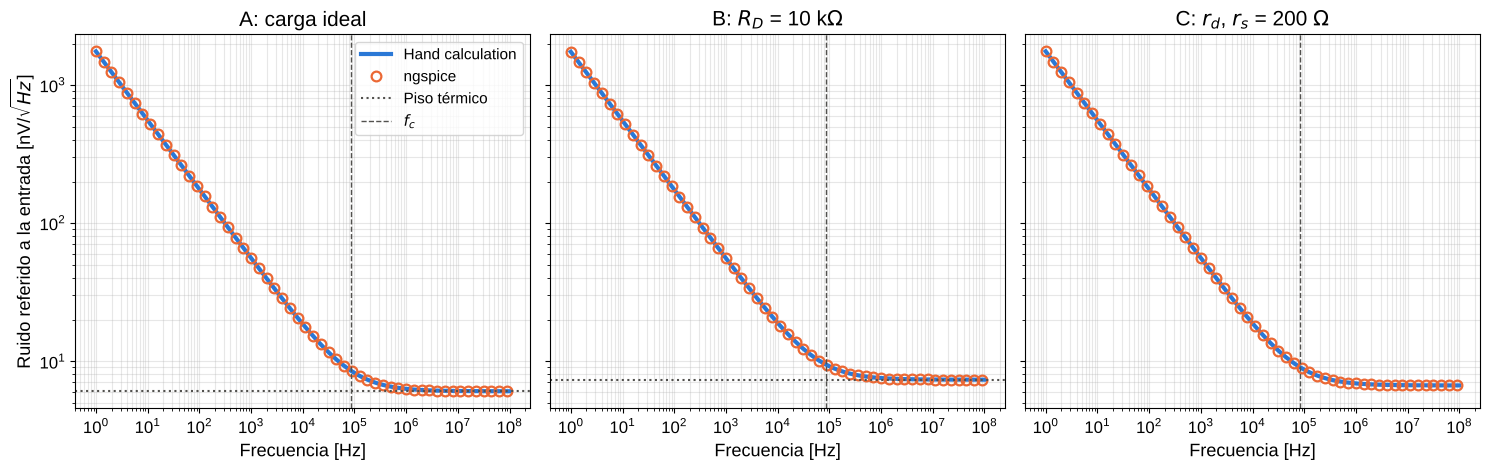

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
panels = [("A: carga ideal", SinA_hand, SinA_sim, opA, S_id_th(opA["gm"]) / opA["gm"]**2),
          (r"B: $R_D$ = 10 k$\Omega$", SinB_hand, SinB_sim, opB, (S_id_th(opB["gm"]) + 4*k*T/RD) / opB["gm"]**2),
          (r"C: $r_d$, $r_s$ = 200 $\Omega$", SinC_hand, SinC_sim, opC, None)]

for ax, (title, h, s, o, th) in zip(axes, panels):
    ax.loglog(f, np.sqrt(h) * 1e9, linewidth=3, color=C_HAND, label="Hand calculation")
    ax.loglog(f[::3], np.sqrt(s[::3]) * 1e9, 'o', markersize=7, mfc='none', mew=1.6, color=C_SIM, label="ngspice")
    if th is not None:
        ax.axhline(np.sqrt(th) * 1e9, color=C_AUX, linestyle=':', linewidth=1.5, label="Piso térmico")
    ax.axvline(fcorner(o), color=C_AUX, linestyle='--', linewidth=1, label=r"$f_c$")
    ax.set_title(title, fontsize=15, weight='normal')
    ax.set_xlabel("Frecuencia [Hz]", fontsize=13)
    ax.tick_params(labelsize=12)
    ax.grid(which='both', alpha=0.3)
axes[0].set_ylabel(r"Ruido referido a la entrada [nV/$\sqrt{Hz}$]", fontsize=13)
axes[0].legend(fontsize=11, loc="upper right")
fig.tight_layout()
plt.show()

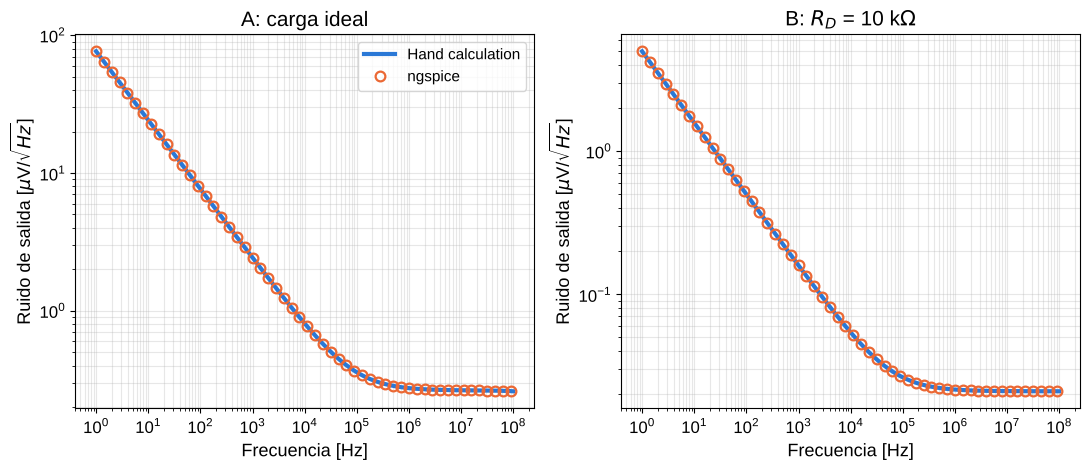

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=False)
for ax, title, h, s in ((axes[0], "A: carga ideal", SoutA_hand, SoutA_sim),
                        (axes[1], r"B: $R_D$ = 10 k$\Omega$", SoutB_hand, SoutB_sim)):
    ax.loglog(f, np.sqrt(h) * 1e6, linewidth=3, color=C_HAND, label="Hand calculation")
    ax.loglog(f[::3], np.sqrt(s[::3]) * 1e6, 'o', markersize=7, mfc='none', mew=1.6, color=C_SIM, label="ngspice")
    ax.set_title(title, fontsize=15, weight='normal')
    ax.set_xlabel("Frecuencia [Hz]", fontsize=13)
    ax.set_ylabel(r"Ruido de salida [$\mu$V/$\sqrt{Hz}$]", fontsize=13)
    ax.tick_params(labelsize=12)
    ax.grid(which='both', alpha=0.3)
axes[0].legend(fontsize=11, loc="upper right")
fig.tight_layout()
plt.show()

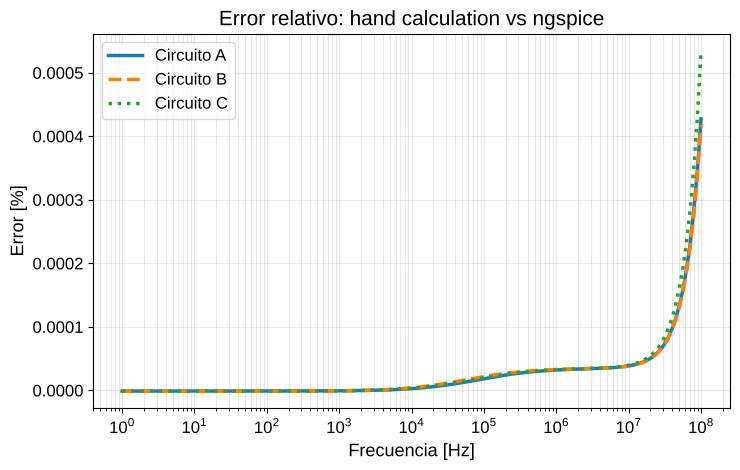

In [11]:
plt.figure(figsize=(7.5, 4.8))
for lab, h, s, ls in (("A", SinA_hand, SinA_sim, "-"), ("B", SinB_hand, SinB_sim, "--"), ("C", SinC_hand, SinC_sim, ":")):
    plt.semilogx(f, (h / s - 1) * 100, ls, linewidth=2.5, label=f"Circuito {lab}")
plt.title("Error relativo: hand calculation vs ngspice", fontsize=15, weight='normal')
plt.xlabel("Frecuencia [Hz]", fontsize=13)
plt.ylabel("Error [%]", fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(which='both', alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Ruido integrado

El ruido rms en una banda $[f_1,\,f_2]$ es la raíz de la integral de la densidad espectral. Para el ruido referido a la entrada de los circuitos A y B, con $S_{V_{in}}(f)=S_{th}+K/f$ y $K=K_FI_D^{A_F}/(g_m^2WLC_{ox}^2)$, la integral tiene forma cerrada:

$$V_{n,in}^2=\int_{f_1}^{f_2}S_{V_{in}}\,df=S_{th}\,(f_2-f_1)+K\ln\frac{f_2}{f_1}.$$

Para el ruido de salida y el circuito C la densidad no es tan simple, así que se integra numéricamente con la regla del trapecio sobre una malla logarítmica densa. ngspice reporta estos totales como `inoise_total` y `onoise_total` en el log, integrados sobre el mismo barrido de 1 Hz a 100 MHz.

In [12]:
# Totales integrados de ngspice (orden: A, B, C)
log_txt = open("Noise_Razavi.log", encoding="utf-8", errors="ignore").read()
inoise_tot = [float(x) for x in re.findall(r"^inoise_total\s*=\s*([-+0-9.eE]+)", log_txt, flags=re.M)]
onoise_tot = [float(x) for x in re.findall(r"^onoise_total\s*=\s*([-+0-9.eE]+)", log_txt, flags=re.M)]

f1, f2 = f[0], f[-1]
fd = np.logspace(np.log10(f1), np.log10(f2), 200001)
trapz = getattr(np, "trapezoid", None) or np.trapz

# Referido a la entrada
Vin_hand = [np.sqrt(trapz(noise_load(opA, fd)[0], fd)),
            np.sqrt(trapz(noise_load(opB, fd, RD)[0], fd)),
            np.sqrt(trapz(noise_with_rd_rs(opC, opC["ID"], fd)[0], fd))]
# Forma cerrada (circuitos A y B)
def closed_form(o, extra_current_noise=0.0):
    Sth = (S_id_th(o["gm"]) + extra_current_noise) / o["gm"]**2
    K = kf * o["ID"]**af / (o["gm"]**2 * W * L * Cox**2)
    return np.sqrt(Sth * (f2 - f1) + K * np.log(f2 / f1))
Vin_closed = [closed_form(opA), closed_form(opB, 4 * k * T / RD)]

# Referido a la salida (con Cout)
Vout_hand = [np.sqrt(trapz(noise_load(opA, fd)[1], fd)),
             np.sqrt(trapz(noise_load(opB, fd, RD)[1], fd))]

myTable = PrettyTable(["Circuito", "Vin rms hand (numerico)", "Vin rms hand (forma cerrada)", "Vin rms ngspice", "Error"])
for i, lab in enumerate("ABC"):
    cf = num2eng(float(Vin_closed[i])) + "V" if i < 2 else "-"
    myTable.add_row([lab, num2eng(float(Vin_hand[i])) + "V", cf, num2eng(inoise_tot[i]) + "V",
                     f"{(Vin_hand[i]/inoise_tot[i]-1)*100:+.3f} %"])
print(f"Ruido integrado de {f1:.0f} Hz a {f2/1e6:.0f} MHz, referido a la entrada\n")
print(myTable)

myTable = PrettyTable(["Circuito", "Vout rms hand", "Vout rms ngspice", "Error"])
for i, lab in enumerate("AB"):
    myTable.add_row([lab, num2eng(float(Vout_hand[i])) + "V", num2eng(onoise_tot[i]) + "V",
                     f"{(Vout_hand[i]/onoise_tot[i]-1)*100:+.3f} %"])
print("\nReferido a la salida\n")
print(myTable)

Ruido integrado de 1 Hz a 100 MHz, referido a la entrada

+----------+-------------------------+------------------------------+-----------------+----------+
| Circuito | Vin rms hand (numerico) | Vin rms hand (forma cerrada) | Vin rms ngspice |  Error   |
+----------+-------------------------+------------------------------+-----------------+----------+
|    A     |         60.9 µV         |           60.9 µV            |     60.9 µV     | -0.047 % |
|    B     |         73.7 µV         |           73.7 µV            |     73.7 µV     | -0.000 % |
|    C     |         67.0 µV         |              -               |     67.1 µV     | -0.064 % |
+----------+-------------------------+------------------------------+-----------------+----------+

Referido a la salida

+----------+---------------+------------------+----------+
| Circuito | Vout rms hand | Vout rms ngspice |  Error   |
+----------+---------------+------------------+----------+
|    A     |     2.6 mV    |      2.6 mV      | +

## Cómo elegir $K_F$

Con $A_F=1$ y en saturación, $f\cdot S_{V_{in},fl}$ no depende de la polarización (sección de ruido flicker), así que $K_F$ se puede despejar a partir de una densidad de ruido 1/f referida a la entrada que se quiera reproducir:

$$K_F=2\,k_p\,W^2\,C_{ox}^2\,(1+\lambda V_{DS})\cdot\left[f\cdot S_{V_{in},fl}\right].$$

Si el dato disponible es la densidad a 1 Hz en V/$\sqrt{\text{Hz}}$, basta elevarla al cuadrado. Este $K_F$ es el de la expresión del Level 1 de ngspice; no es el $K_F'$ (en V$^2\cdot$F) que suelen reportar las fundiciones. La relación entre ambos depende de la forma de la fórmula que use cada simulador, así que conviene calibrar contra el propio simulador.

In [13]:
def kf_from_input_noise(S_in_1Hz, VDS_=0.9):
    """KF para af = 1 en saturacion, a partir de la densidad 1/f referida a la entrada a 1 Hz (V^2/Hz)."""
    return 2 * kp * W**2 * Cox**2 * (1 + lmbda * VDS_) * S_in_1Hz


target = 1.75e-6   # V/rtHz a 1 Hz
print(f"Para {target*1e6:.2f} uV/rtHz a 1 Hz (af = 1, W = 1u, L = 0.18u): KF = {kf_from_input_noise(target**2):.3e}   (usado en la libreria: {kf:.1e})")

Para 1.75 uV/rtHz a 1 Hz (af = 1, W = 1u, L = 0.18u): KF = 4.976e-32   (usado en la libreria: 5.0e-32)
